In [38]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from itertools import combinations
from math import factorial

In [39]:
def make_sigma(p, rho):
    """Construct Sigma with entries rho^{|j-k|}."""
    Sigma = np.zeros((p, p))
    for j in range(p):
        for k in range(p):
            Sigma[j, k] = rho ** abs(j - k)
    return Sigma

def simulate_dataset(n, mu, Sigma, beta0, beta, sigma_eps, seed=None):
    """
    Simulate one dataset:
      X ~ N(mu, Sigma)
      Y = beta0 + X beta + eps
    using one RNG seed.
    """
    rng = np.random.default_rng(seed)
    X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
    eps = rng.normal(loc=0.0, scale=sigma_eps, size=n)
    y = beta0 + X @ beta + eps
    return X, y

def aggregate_dependence_curve(x_vals, shap_vals, nbins=30):
    """
    Bin x-values and compute mean/SD of SHAP within bins.
    Returns bin centers, mean SHAP, SD SHAP, counts.
    """
    bins = np.linspace(np.min(x_vals), np.max(x_vals), nbins + 1)
    bin_ids = np.digitize(x_vals, bins) - 1

    centers = []
    means = []
    sds = []
    counts = []

    for b in range(nbins):
        mask = bin_ids == b
        if np.sum(mask) > 5:
            centers.append(np.mean(x_vals[mask]))
            means.append(np.mean(shap_vals[mask]))
            sds.append(np.std(shap_vals[mask], ddof=1))
            counts.append(np.sum(mask))

    return np.array(centers), np.array(means), np.array(sds), np.array(counts)

def coalition_value_conditional_linear(x, beta, Sigma, S, mu=None):
    """
    Exact conditional coalition value for a linear model:
        v_x(S) = E[f(X) | X_S = x_S] - E[f(X)]
    where f(x) = beta0 + beta^T x.
    beta0 drops out after centering.
    """
    p = len(beta)
    if mu is None:
        mu = np.zeros(p)

    S = list(S)
    C = [j for j in range(p) if j not in S]

    dx = x - mu

    # empty coalition
    if len(S) == 0:
        return 0.0

    # full coalition
    if len(S) == p:
        return beta @ dx

    # conditional mean of X_C given X_S = x_S
    Sigma_SS = Sigma[np.ix_(S, S)]
    Sigma_CS = Sigma[np.ix_(C, S)]

    cond_mean_C = mu[C] + Sigma_CS @ np.linalg.solve(Sigma_SS, dx[S])

    val = beta[S] @ dx[S] + beta[C] @ (cond_mean_C - mu[C])
    return val

def true_conditional_shap_linear(x, beta, Sigma, mu=None):
    """
    Exact conditional SHAP values for a linear model under Gaussian X.
    """
    p = len(beta)
    if mu is None:
        mu = np.zeros(p)

    N = list(range(p))
    phi = np.zeros(p)

    for j in range(p):
        others = [k for k in N if k != j]

        for s in range(len(others) + 1):
            for S in combinations(others, s):
                S = set(S)
                weight = factorial(len(S)) * factorial(p - len(S) - 1) / factorial(p)

                v_with_j = coalition_value_conditional_linear(
                    x=x, beta=beta, Sigma=Sigma, S=S.union({j}), mu=mu
                )
                v_without_j = coalition_value_conditional_linear(
                    x=x, beta=beta, Sigma=Sigma, S=S, mu=mu
                )

                phi[j] += weight * (v_with_j - v_without_j)

    return phi


In [44]:
n = 500
n_reps = 100
p = 500
rho = 0.0
sigma_eps = 1.0

feature_names = [f"X{j+1}" for j in range(p)]

beta0 = 1.5
# beta = np.array([0.5, 2.0, -1.0, 1.5, -1.0])
beta = np.zeros(p)
beta[:5] = np.array([0.5, 2.0, -1.0, 1.5, -1.0])

mu = np.zeros(p)   # mean vector
rho = 0.0                        # requested first case
Sigma = make_sigma(p, rho)

# =========================================================
# 3. Fix the design matrix once
# =========================================================

rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

# true SHAP values under the true linear model
true_phi = (X - mu.reshape(1, -1)) * beta.reshape(1, -1)

# storage for SHAP estimates across replications
shap_store = np.zeros((n_reps, n, p))
base_store = np.zeros((n_reps, n))

coef_store = np.zeros((n_reps, p))
intercept_store = np.zeros(n_reps)

In [46]:
for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    eps = rng_rep.normal(loc=0.0, scale=sigma_eps, size=n)
    y = beta0 + X @ beta + eps

    model = LinearRegression()
    model.fit(X_df, y)
    coef_store[rep, :] = model.coef_
    intercept_store[rep] = model.intercept_

    explainer = shap.Explainer(model, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# average SHAP over replications
avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

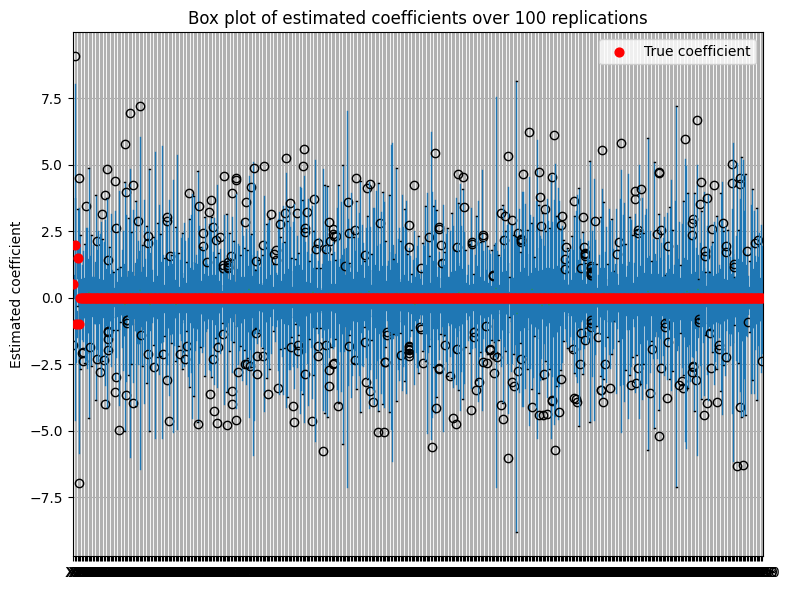

In [47]:
import matplotlib.pyplot as plt
import pandas as pd



coef_df = pd.DataFrame(coef_store, columns=feature_names)

fig, ax = plt.subplots(figsize=(8, 6))
coef_df.boxplot(ax=ax)

# add true beta values as red points / horizontal markers
for j, true_b in enumerate(beta, start=1):
    ax.scatter(j, true_b, color="red", s=40, zorder=3, label="True coefficient" if j == 1 else "")

ax.set_title(f"Box plot of estimated coefficients over {n_reps} replications")
ax.set_ylabel("Estimated coefficient")
ax.legend()

fig.tight_layout()
fig.savefig("boxplot_estimated_coefficients.pdf", bbox_inches="tight")
#fig.savefig("boxplot_estimated_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

In [48]:
print(coef_df)

          X1        X2        X3        X4        X5        X6        X7  \
0   1.317400  4.731257 -0.358328  3.151956  2.783002 -0.958654 -0.244896   
1  -0.030600  3.232381 -0.714735  1.068233 -0.623838 -0.604578 -0.122377   
2  -0.208448  0.129074 -1.533284  0.600118 -4.295465 -0.102572  0.645526   
3   1.042430  3.387072 -0.458891  2.666212  1.712803 -0.176148 -0.305289   
4  -0.350881  3.421352 -0.787150  0.466329 -1.917763 -0.310404  0.981859   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.615414  4.778385 -0.183878  1.110043  0.235913 -1.355750  0.199578   
96 -0.152474  0.607551 -1.455291  0.472055 -3.372509  0.519246 -0.091165   
97  0.673262  1.716843 -1.098215  1.616003 -0.368987 -0.251370 -0.782310   
98 -0.830362 -0.165437 -1.568883  0.149038 -5.834103  0.715605  0.806460   
99 -0.289771  3.705109 -0.491009  1.706390 -0.254854 -0.783278  0.583060   

          X8        X9       X10  ...      X491      X492      X493      X494  \
0   0.

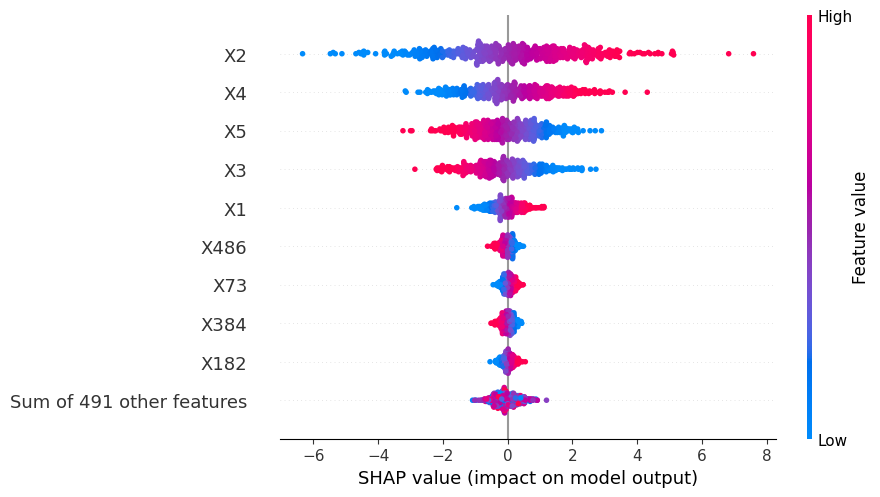

In [49]:
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

shap.plots.beeswarm(avg_explanation, max_display=10, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_sparse_high_linear1.pdf", bbox_inches="tight")
plt.show()

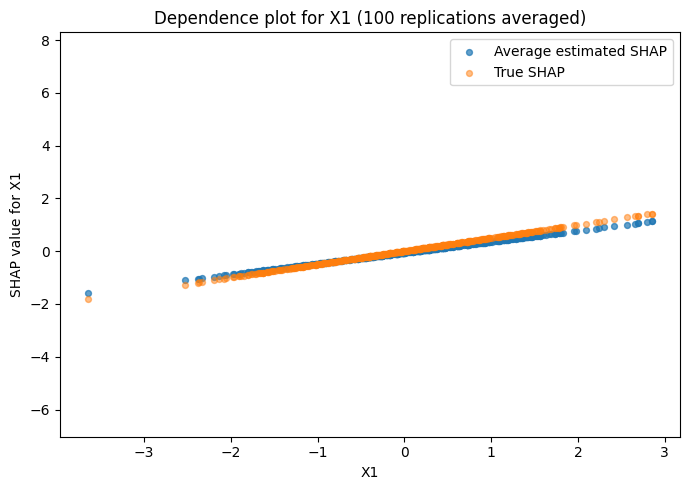

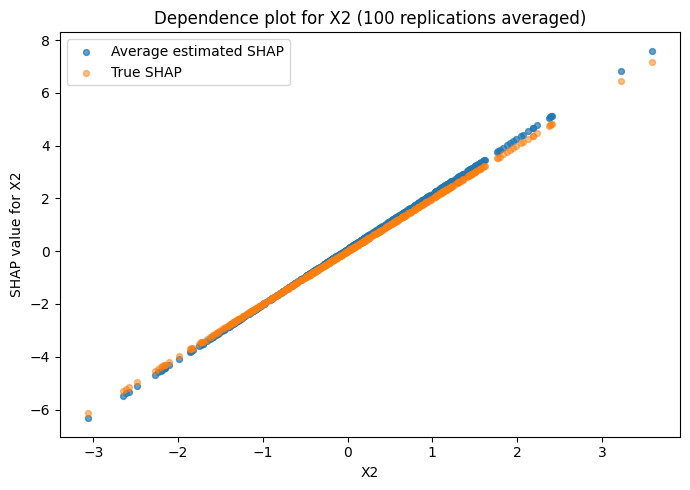

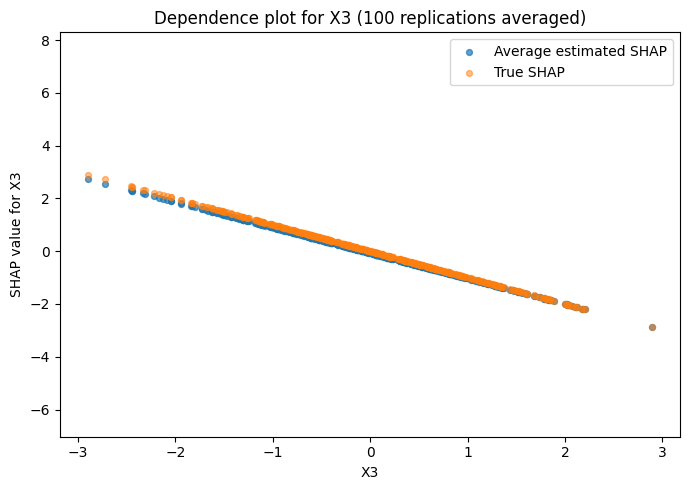

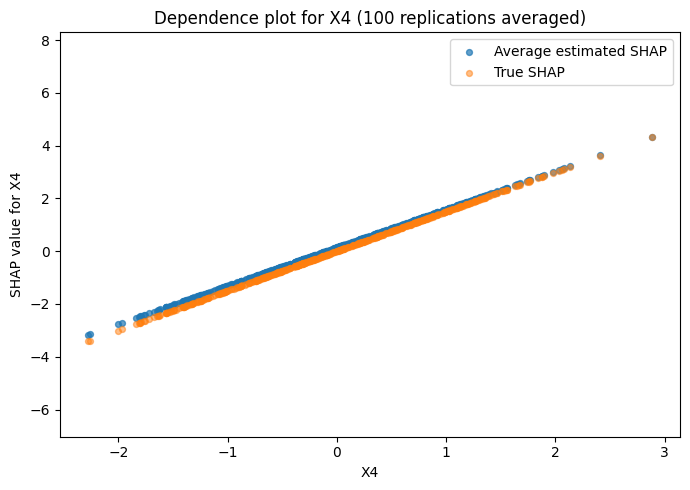

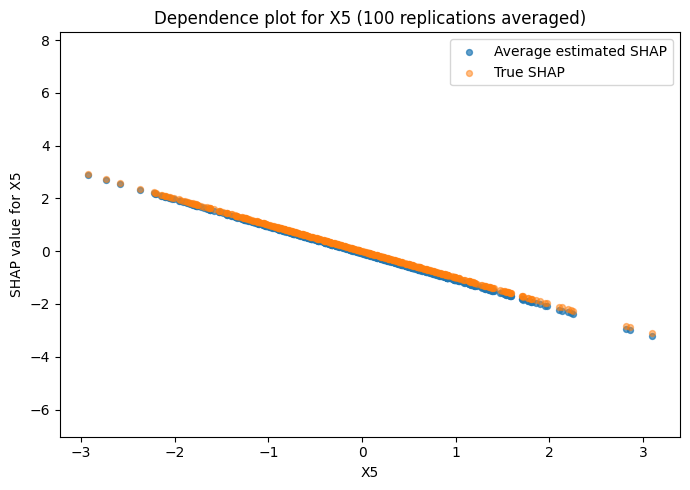

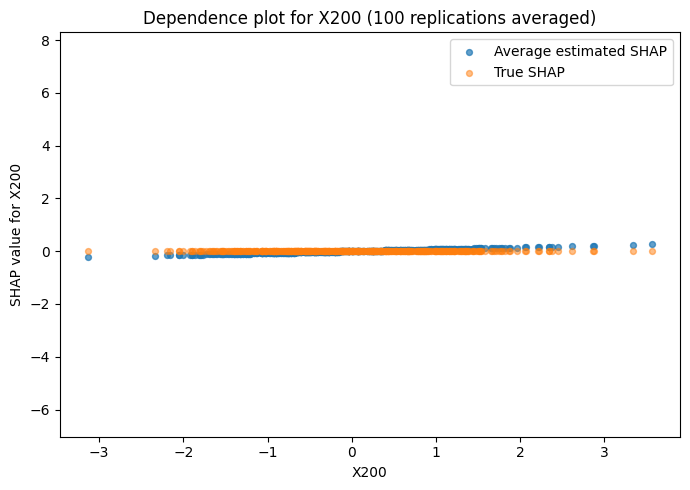

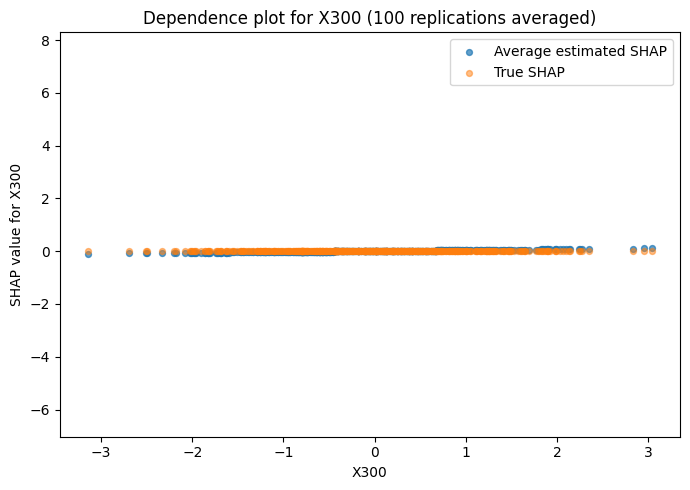

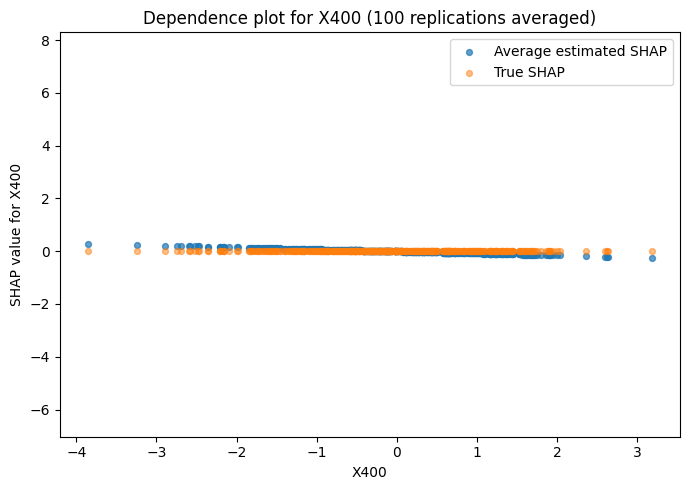

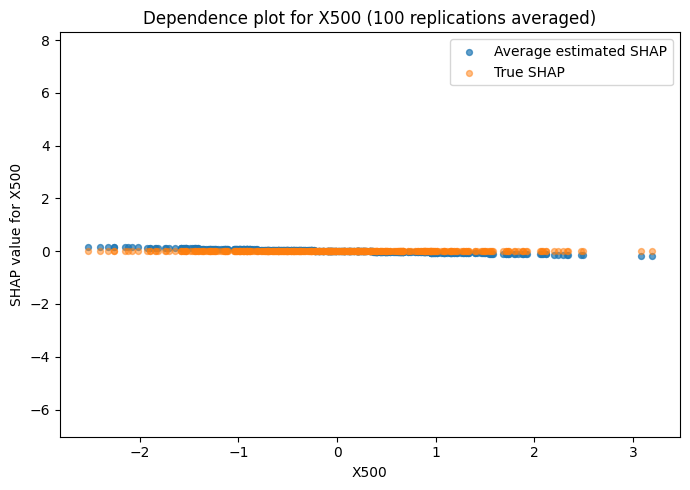

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# only keep the true active features
active_idx = [0, 1, 2, 3, 4, 199, 299, 399, 499]
active_names = [feature_names[j] for j in active_idx]

# common y-limits across X1,...,X5 only
y_min = min(np.min(avg_shap[:, j]) for j in active_idx)
y_max = max(np.max(avg_shap[:, j]) for j in active_idx)

# also include truth
y_min = min(y_min, min(np.min(true_phi[:, j]) for j in active_idx))
y_max = max(y_max, max(np.max(true_phi[:, j]) for j in active_idx))

y_pad = 0.05 * (y_max - y_min)
y_lim = (y_min - y_pad, y_max + y_pad)

for j, name in zip(active_idx, active_names):
    x_min = np.min(X[:, j])
    x_max = np.max(X[:, j])
    x_pad = 0.05 * (x_max - x_min)
    x_lim = (x_min - x_pad, x_max + x_pad)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        X[:, j],
        avg_shap[:, j],
        alpha=0.7,
        s=18,
        label="Average estimated SHAP"
    )

    ax.scatter(
        X[:, j],
        true_phi[:, j],
        alpha=0.5,
        s=18,
        label="True SHAP"
    )

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)

    ax.set_xlabel(name)
    ax.set_ylabel(f"SHAP value for {name}")
    ax.set_title(f"Dependence plot for {name} ({n_reps} replications averaged)")
    ax.legend()

    fig.tight_layout()
    fig.savefig(f"dependence_{name}_sparse_high_linear1.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [30]:
n = 500
n_reps = 100
p = 500
rho = 0.50
sigma_eps = 1.0

feature_names = [f"X{j+1}" for j in range(p)]

beta0 = 1.5
# beta = np.array([0.5, 2.0, -1.0, 1.5, -1.0])
beta = np.zeros(p)
beta[:5] = np.array([0.5, 2.0, -1.0, 1.5, -1.0])

mu = np.zeros(p)   # mean vector
Sigma = make_sigma(p, rho)

# =========================================================
# 3. Fix the design matrix once
# =========================================================

rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

# true SHAP values under the true linear model
true_phi = (X - mu.reshape(1, -1)) * beta.reshape(1, -1)

# storage for SHAP estimates across replications
shap_store = np.zeros((n_reps, n, p))
base_store = np.zeros((n_reps, n))

coef_store = np.zeros((n_reps, p))
intercept_store = np.zeros(n_reps)

In [31]:
for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    eps = rng_rep.normal(loc=0.0, scale=sigma_eps, size=n)
    y = beta0 + X @ beta + eps

    model = LinearRegression()
    model.fit(X_df, y)

    explainer = shap.Explainer(model, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# average SHAP over replications
avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

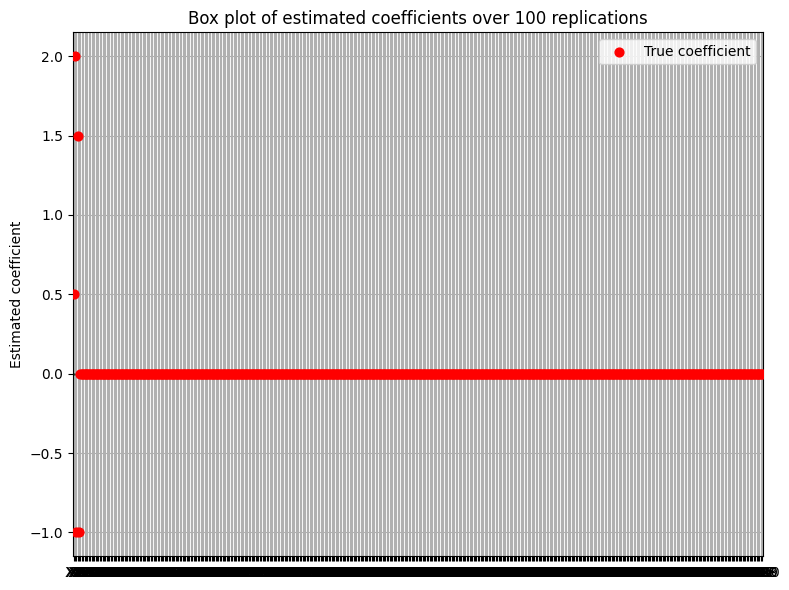

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

coef_df = pd.DataFrame(coef_store, columns=feature_names)

fig, ax = plt.subplots(figsize=(8, 6))
coef_df.boxplot(ax=ax)

# add true beta values as red points / horizontal markers
for j, true_b in enumerate(beta, start=1):
    ax.scatter(j, true_b, color="red", s=40, zorder=3, label="True coefficient" if j == 1 else "")

ax.set_title(f"Box plot of estimated coefficients over {n_reps} replications")
ax.set_ylabel("Estimated coefficient")
ax.legend()

fig.tight_layout()
fig.savefig("boxplot_estimated_coefficients.pdf", bbox_inches="tight")
#fig.savefig("boxplot_estimated_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

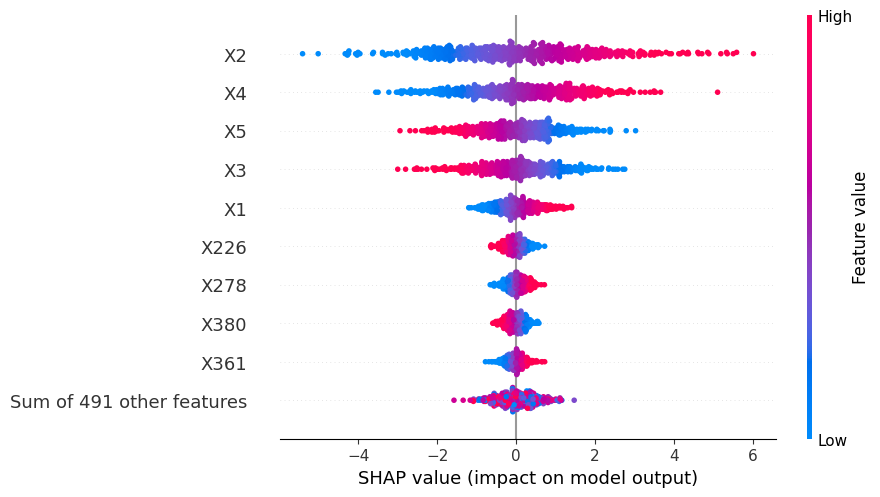

In [33]:
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

shap.plots.beeswarm(avg_explanation, max_display=10, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_sparse_high_linear1.pdf", bbox_inches="tight")
plt.show()